# 🏥 Healthcare Analytics for Doctor Visits

## Understanding the Factors Associated with Doctor Visits

Healthcare data contains information about people, their health
conditions, and their healthcare usage.

But raw data does not immediately tell us:

### "Why do doctor visits differ between people?"

In this project, we explore this question step by step.

### Our Story

**People → Health → Healthcare Access → Doctor Visits → Insights**

We will use data analysis, visualization, and statistical techniques
to discover meaningful patterns in the dataset.

Import Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu

print("Libraries imported successfully!")
print("Ready to begin the healthcare analytics journey.")

Libraries imported successfully!
Ready to begin the healthcare analytics journey.


Load the Dataset

In [29]:
df = pd.read_csv("/content/Healthcare Analytics for Doctor Visits.csv")

print("Dataset loaded successfully!")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")S

Dataset loaded successfully!
Rows    : 5190
Columns : 13


View the Data

In [30]:
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [31]:
print("Dataset dimensions:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Dataset dimensions: (5190, 13)

Column names:
['Unnamed: 0', 'visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']


Understand the Variables

In [32]:
print("Data Types:\n")
print(df.dtypes)

print("\nUnique Values:\n")

for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

Data Types:

Unnamed: 0      int64
visits          int64
gender         object
age           float64
income        float64
illness         int64
reduced         int64
health          int64
private        object
freepoor       object
freerepat      object
nchronic       object
lchronic       object
dtype: object

Unique Values:

Unnamed: 0: 5190 unique values
visits: 10 unique values
gender: 2 unique values
age: 12 unique values
income: 14 unique values
illness: 6 unique values
reduced: 15 unique values
health: 13 unique values
private: 2 unique values
freepoor: 2 unique values
freerepat: 2 unique values
nchronic: 2 unique values
lchronic: 2 unique values


Data Quality Check

In [33]:
print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64

Total Missing Values: 0

Duplicate Rows: 0


In [34]:
print("\nData information:")
df.info()


Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


Remove the Index Column

In [35]:
analysis_df = df.copy()

if 'Unnamed: 0' in analysis_df.columns:
    analysis_df = analysis_df.drop(columns=['Unnamed: 0'])

print("Index-like column removed.")
print("Analysis dataset shape:", analysis_df.shape)

Index-like column removed.
Analysis dataset shape: (5190, 12)


Statistical Summary

In [36]:
analysis_df.describe()

,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


Our First Question: Doctor Visits

In [37]:
visit_counts = analysis_df['visits'].value_counts().sort_index()

print("Doctor Visit Distribution:")
print(visit_counts)

print("\nAverage visits:", round(analysis_df['visits'].mean(), 3))
print("Median visits :", analysis_df['visits'].median())

Doctor Visit Distribution:
visits
0    4141
1     782
2     174
3      30
4      24
5       9
6      12
7      12
8       5
9       1
Name: count, dtype: int64

Average visits: 0.302
Median visits : 0.0


Doctor Visit Visualization

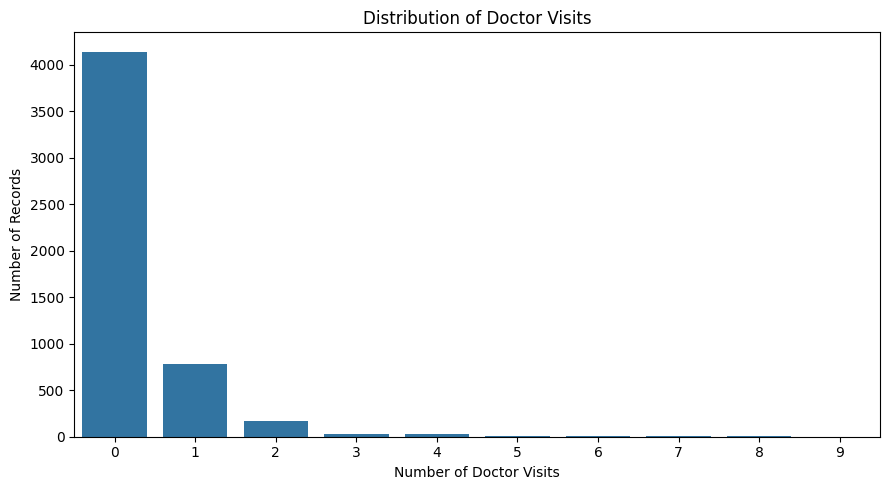

In [38]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=analysis_df,
    x='visits'
)

plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Doctor Visits')
plt.ylabel('Number of Records')

plt.tight_layout()
plt.show()

Question 2: Age

In [39]:
age_summary = (
    analysis_df
    .groupby('age')['visits']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

age_summary

,age,count,mean,median
0,0.19,752,0.212766,0.0
1,0.22,1213,0.201154,0.0
2,0.27,523,0.258126,0.0
3,0.32,301,0.242525,0.0
4,0.37,146,0.246575,0.0
5,0.42,126,0.317460,0.0
6,0.47,181,0.270718,0.0
7,0.52,222,0.414414,0.0
8,0.57,273,0.399267,0.0
9,0.62,316,0.354430,0.0


Age Visualization

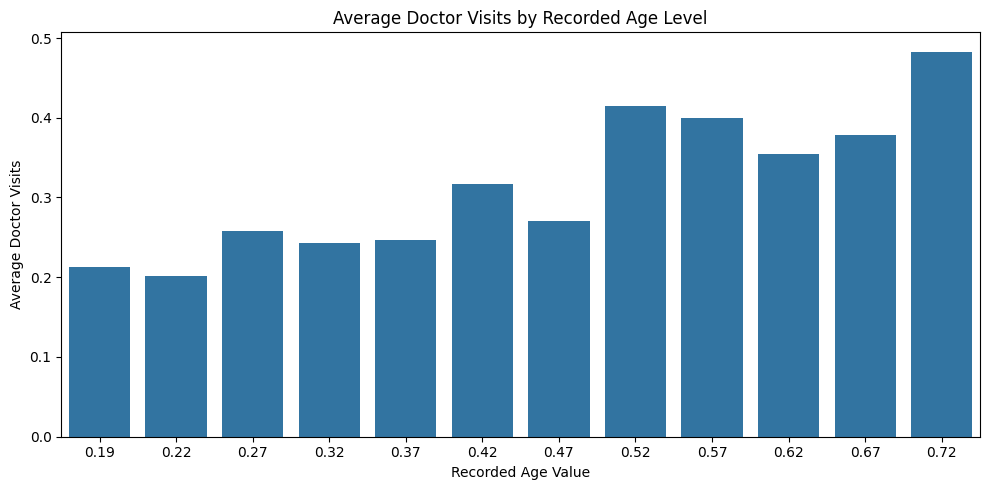

In [40]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=age_summary,
    x='age',
    y='mean'
)

plt.title('Average Doctor Visits by Recorded Age Level')
plt.xlabel('Recorded Age Value')
plt.ylabel('Average Doctor Visits')

plt.tight_layout()
plt.show()

Age Statistical Relationship

In [41]:
age_corr, age_p = spearmanr(
    analysis_df['age'],
    analysis_df['visits']
)

print(f"Spearman correlation between age and visits: {age_corr:.3f}")
print(f"P-value: {age_p:.5e}")

Spearman correlation between age and visits: 0.148
P-value: 1.17785e-26


Question 3: Illness

In [42]:
illness_summary = (
    analysis_df
    .groupby('illness')['visits']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

illness_summary

,illness,count,mean,median
0,0,1554,0.078507,0.0
1,1,1638,0.295482,0.0
2,2,946,0.403805,0.0
3,3,542,0.420664,0.0
4,4,274,0.576642,0.0
5,5,236,0.813559,0.0


Illness Visualization

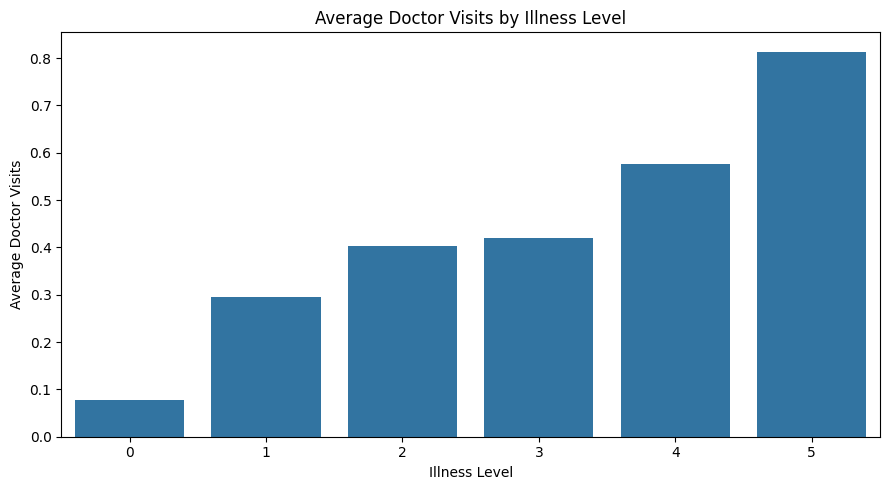

In [43]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=illness_summary,
    x='illness',
    y='mean'
)

plt.title('Average Doctor Visits by Illness Level')
plt.xlabel('Illness Level')
plt.ylabel('Average Doctor Visits')

plt.tight_layout()
plt.show()

Illness Statistical Relationship

In [44]:
illness_corr, illness_p = spearmanr(
    analysis_df['illness'],
    analysis_df['visits']
)

print(f"Spearman correlation: {illness_corr:.3f}")
print(f"P-value: {illness_p:.5e}")

Spearman correlation: 0.263
P-value: 1.19923e-82


Question 4: Reduced Activity

In [47]:
reduced_summary = (
    analysis_df
    .groupby('reduced')['visits']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

print("Average Doctor Visits by Reduced Activity:")
display(reduced_summary)

Average Doctor Visits by Reduced Activity:


,reduced,count,mean,median
0,0,4454,0.183880,0.0
1,1,177,0.355932,0.0
2,2,108,0.574074,0.0
3,3,74,1.094595,1.0
4,4,45,0.800000,1.0
5,5,40,1.275000,1.0
6,6,17,1.176471,1.0
7,7,38,1.184211,1.0
8,8,17,1.176471,1.0
9,9,7,1.714286,1.0


Reduced Activity Visualization

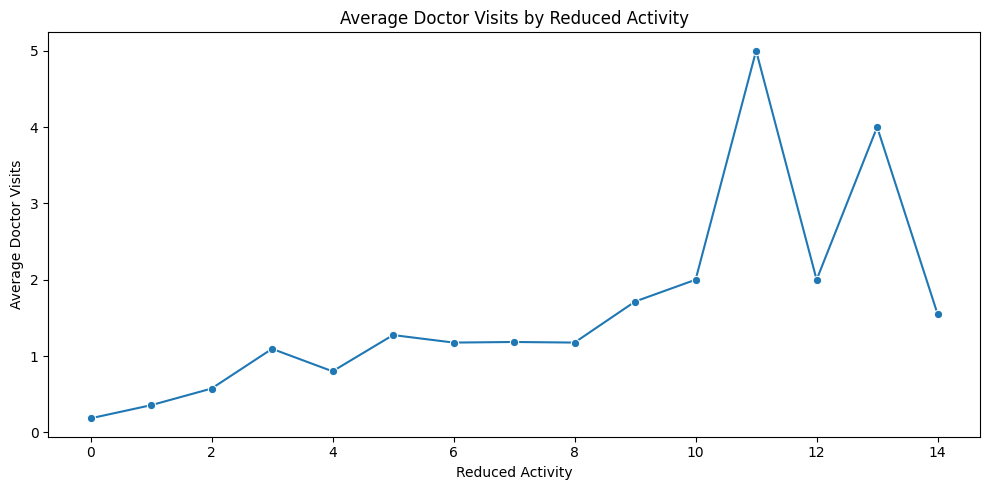

In [48]:
# Visualization

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=reduced_summary,
    x='reduced',
    y='mean',
    marker='o'
)

plt.title('Average Doctor Visits by Reduced Activity')
plt.xlabel('Reduced Activity')
plt.ylabel('Average Doctor Visits')

plt.tight_layout()
plt.show()

Reduced Activity Statiscal Analysis

In [49]:
# Spearman Correlation

from scipy.stats import spearmanr

reduced_corr, reduced_p = spearmanr(
    analysis_df['reduced'],
    analysis_df['visits']
)

print(f"Spearman correlation: {reduced_corr:.3f}")
print(f"P-value: {reduced_p:.5e}")

Spearman correlation: 0.336
P-value: 8.44882e-137


Question 5: Health

In [50]:
health_summary = (
    analysis_df
    .groupby('health')['visits']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

health_summary

,health,count,mean,median
0,0,3026,0.199273,0.0
1,1,823,0.335358,0.0
2,2,446,0.381166,0.0
3,3,273,0.417582,0.0
4,4,187,0.534759,0.0
5,5,132,0.530303,0.0
6,6,104,0.625000,0.0
7,7,61,0.918033,0.0
8,8,42,0.476190,0.0
9,9,32,0.656250,0.0


Health Visualization

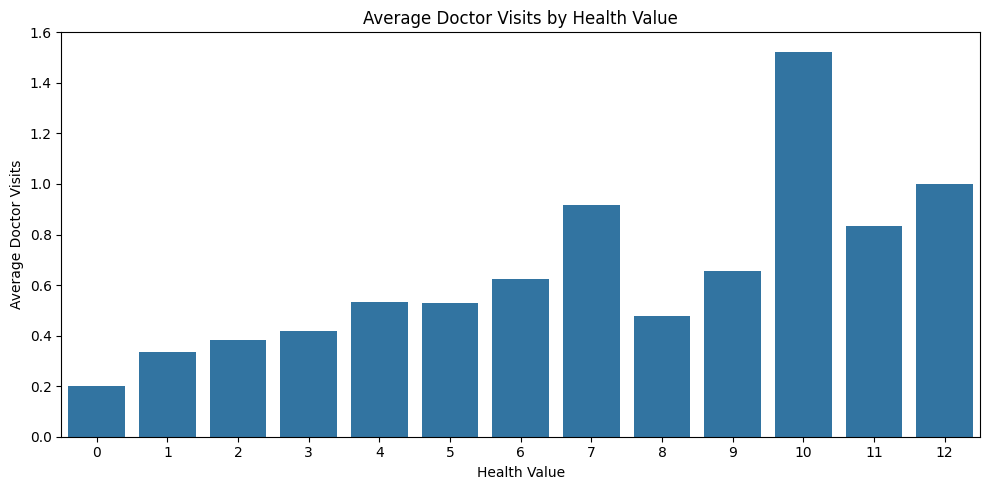

In [51]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=health_summary,
    x='health',
    y='mean'
)

plt.title('Average Doctor Visits by Health Value')
plt.xlabel('Health Value')
plt.ylabel('Average Doctor Visits')

plt.tight_layout()
plt.show()

Health Correlation

In [52]:
health_corr, health_p = spearmanr(
    analysis_df['health'],
    analysis_df['visits']
)

print(f"Spearman correlation: {health_corr:.3f}")
print(f"P-value: {health_p:.5e}")

Spearman correlation: 0.178
P-value: 5.22335e-38


Question 6: Gender

In [53]:
gender_summary = (
    analysis_df
    .groupby('gender')['visits']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

gender_summary

,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


Gender Visualization

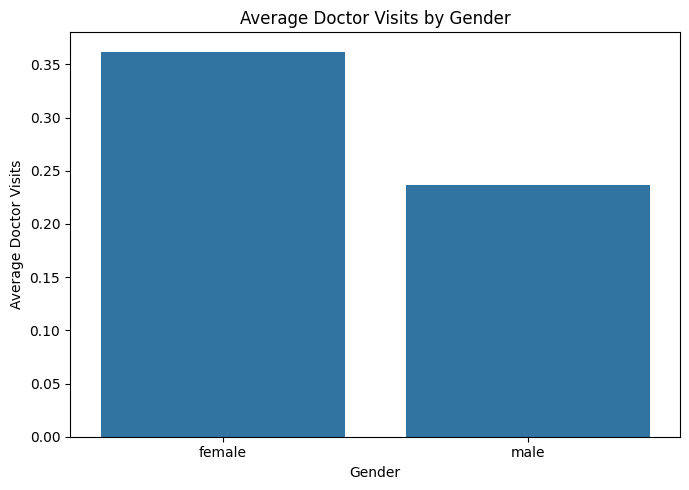

In [54]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=gender_summary,
    x='gender',
    y='mean'
)

plt.title('Average Doctor Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Doctor Visits')

plt.tight_layout()
plt.show()

Gender Statistical Analysis

In [55]:
gender_groups = [
    group['visits'].values
    for _, group in analysis_df.groupby('gender')
]

u_stat, gender_p = mannwhitneyu(
    gender_groups[0],
    gender_groups[1],
    alternative='two-sided'
)

print(f"Mann-Whitney U statistic: {u_stat:.2f}")
print(f"P-value: {gender_p:.5e}")

Mann-Whitney U statistic: 3655194.50
P-value: 6.33828e-15


Question 7: Chronic Conditions

In [56]:
for column in ['nchronic', 'lchronic']:

    summary = (
        analysis_df
        .groupby(column)['visits']
        .agg(['count', 'mean', 'median'])
        .reset_index()
    )

    print(f"\n{column}")
    display(summary)


nchronic


,nchronic,count,mean,median
0,no,3098,0.272111,0.0
1,yes,2092,0.345602,0.0



lchronic


,lchronic,count,mean,median
0,no,4585,0.261941,0.0
1,yes,605,0.603306,0.0


Chronic Condition Visualization

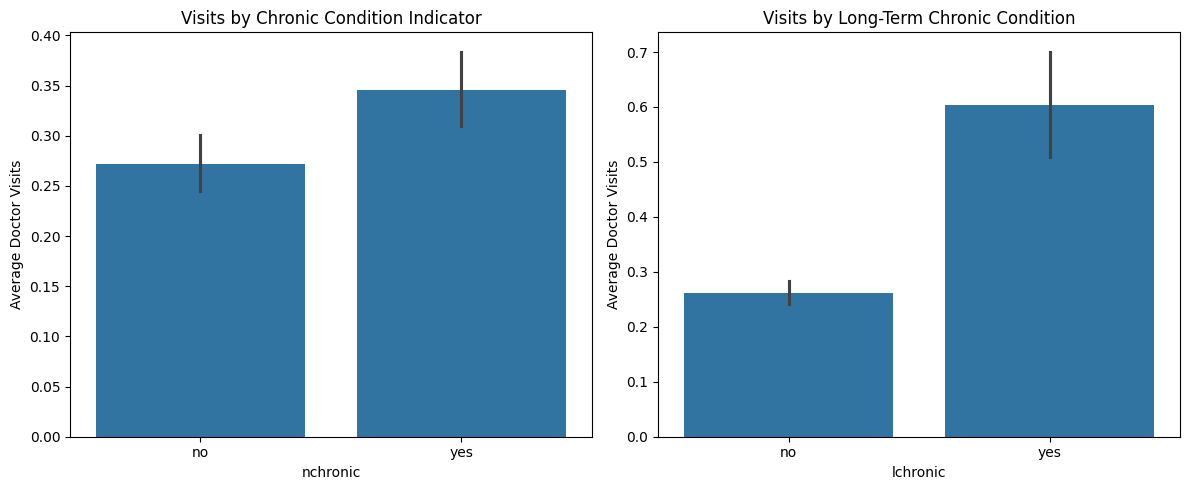

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.barplot(
    data=analysis_df,
    x='nchronic',
    y='visits',
    ax=axes[0]
)

axes[0].set_title('Visits by Chronic Condition Indicator')
axes[0].set_xlabel('nchronic')
axes[0].set_ylabel('Average Doctor Visits')

sns.barplot(
    data=analysis_df,
    x='lchronic',
    y='visits',
    ax=axes[1]
)

axes[1].set_title('Visits by Long-Term Chronic Condition')
axes[1].set_xlabel('lchronic')
axes[1].set_ylabel('Average Doctor Visits')

plt.tight_layout()
plt.show()

Healthcare Access Variables

In [58]:
access_columns = ['private', 'freepoor', 'freerepat']

for column in access_columns:

    summary = (
        analysis_df
        .groupby(column)['visits']
        .agg(['count', 'mean', 'median'])
        .reset_index()
    )

    print(f"\n===== {column} =====")
    display(summary)


===== private =====


,private,count,mean,median
0,no,2892,0.307400,0.0
1,yes,2298,0.294604,0.0



===== freepoor =====


,freepoor,count,mean,median
0,no,4968,0.308172,0.0
1,yes,222,0.157658,0.0



===== freerepat =====


,freerepat,count,mean,median
0,no,4099,0.257868,0.0
1,yes,1091,0.466544,0.0


Healthcare Access Visualization

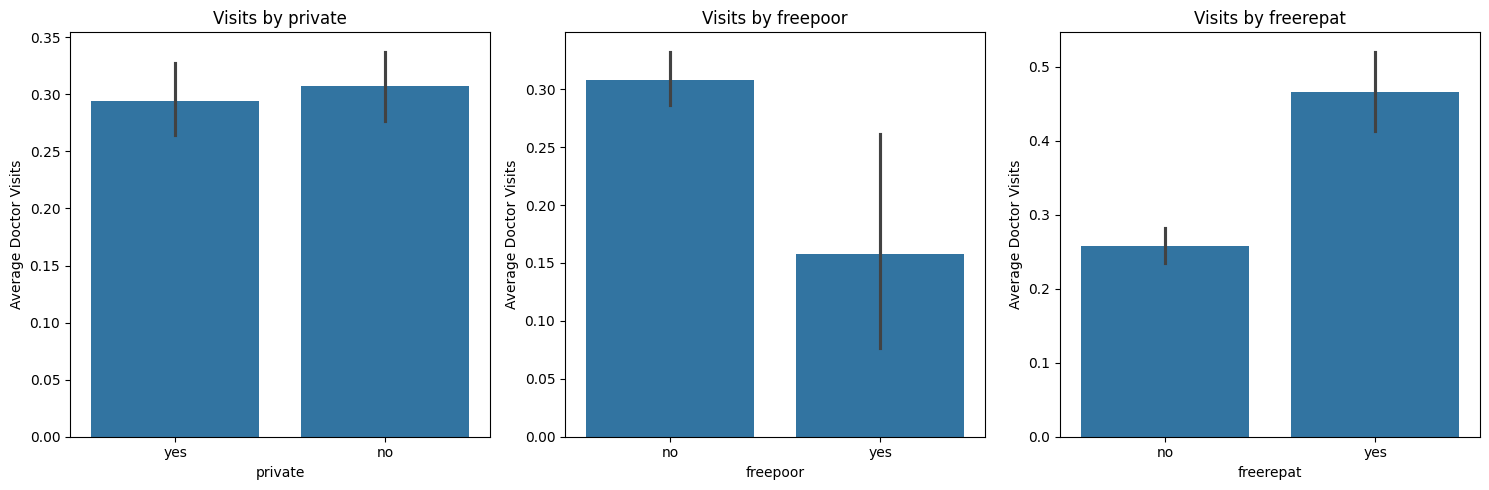

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, column in zip(axes, access_columns):

    sns.barplot(
        data=analysis_df,
        x=column,
        y='visits',
        ax=ax
    )

    ax.set_title(f'Visits by {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Average Doctor Visits')

plt.tight_layout()
plt.show()

Income

In [60]:
income_summary = (
    analysis_df
    .groupby('income')['visits']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

income_summary

,income,count,mean,median
0,0.00,79,0.367089,0.0
1,0.01,35,0.485714,0.0
2,0.06,80,0.200000,0.0
3,0.15,249,0.349398,0.0
4,0.25,1195,0.420921,0.0
5,0.35,462,0.359307,0.0
6,0.45,400,0.305000,0.0
7,0.55,467,0.252677,0.0
8,0.65,455,0.246154,0.0
9,0.75,441,0.244898,0.0


Income Visualization

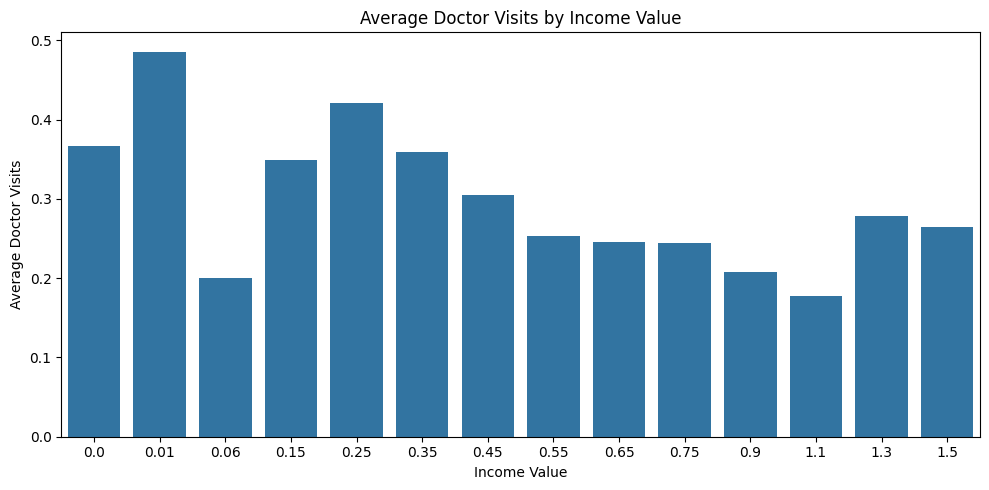

In [61]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=income_summary,
    x='income',
    y='mean'
)

plt.title('Average Doctor Visits by Income Value')
plt.xlabel('Income Value')
plt.ylabel('Average Doctor Visits')

plt.tight_layout()
plt.show()

Income Correlation

In [62]:
income_corr, income_p = spearmanr(
    analysis_df['income'],
    analysis_df['visits']
)

print(f"Spearman correlation: {income_corr:.3f}")
print(f"P-value: {income_p:.5e}")

Spearman correlation: -0.093
P-value: 2.11371e-11


BIG QUESTION: Compare All Numeric Factors

In [63]:
numeric_columns = [
    'visits',
    'age',
    'income',
    'illness',
    'reduced',
    'health'
]

correlation_matrix = analysis_df[numeric_columns].corr(
    method='spearman'
)

print("Spearman Correlation with Doctor Visits:\n")

print(
    correlation_matrix['visits']
    .sort_values(ascending=False)
)

Spearman Correlation with Doctor Visits:

visits     1.000000
reduced    0.335574
illness    0.262679
health     0.177524
age        0.147560
income    -0.092795
Name: visits, dtype: float64


Correlation Heatmap

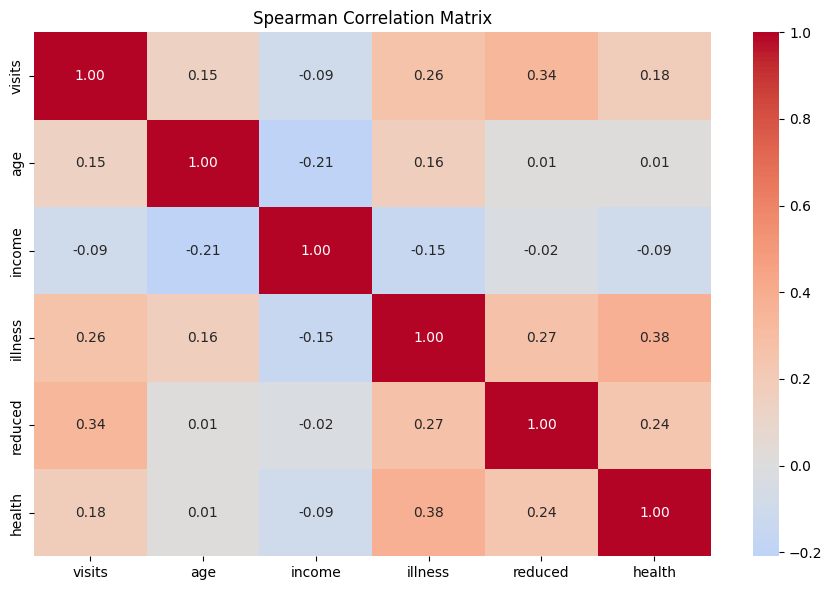

In [64]:
plt.figure(figsize=(9,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Spearman Correlation Matrix')

plt.tight_layout()
plt.show()

Automatically Find Strongest Relationships

In [65]:
visit_correlations = (
    correlation_matrix['visits']
    .drop('visits')
    .sort_values(key=abs, ascending=False)
)

print("Variables ranked by absolute Spearman association with visits:\n")

for variable, value in visit_correlations.items():
    print(f"{variable:10s} : {value:.3f}")

Variables ranked by absolute Spearman association with visits:

reduced    : 0.336
illness    : 0.263
health     : 0.178
age        : 0.148
income     : -0.093


Generate a Professional Summary Automatically

In [66]:
print("=" * 65)
print("        HEALTHCARE ANALYTICS FOR DOCTOR VISITS")
print("=" * 65)

print(f"\nDataset Records : {len(analysis_df)}")
print(f"Average Visits  : {analysis_df['visits'].mean():.3f}")
print(f"Median Visits   : {analysis_df['visits'].median():.1f}")

print("\nSpearman Associations with Doctor Visits:")

for variable, value in visit_correlations.items():
    print(f"  {variable:<10} : {value:.3f}")

strongest_variable = visit_correlations.index[0]
strongest_value = visit_correlations.iloc[0]

print("\n" + "-" * 65)

print(
    f"\nStrongest absolute association among the selected "
    f"numeric variables: {strongest_variable}"
)

print(
    f"Spearman correlation: {strongest_value:.3f}"
)

print("\n" + "-" * 65)

print("STORY:")
print("Raw Healthcare Data")
print("        ↓")
print("Data Quality & Exploration")
print("        ↓")
print("Demographic Analysis")
print("        ↓")
print("Health & Chronic Conditions")
print("        ↓")
print("Healthcare Access")
print("        ↓")
print("Statistical Analysis")
print("        ↓")
print("Meaningful Insights")
print("=" * 65)

        HEALTHCARE ANALYTICS FOR DOCTOR VISITS

Dataset Records : 5190
Average Visits  : 0.302
Median Visits   : 0.0

Spearman Associations with Doctor Visits:
  reduced    : 0.336
  illness    : 0.263
  health     : 0.178
  age        : 0.148
  income     : -0.093

-----------------------------------------------------------------

Strongest absolute association among the selected numeric variables: reduced
Spearman correlation: 0.336

-----------------------------------------------------------------
STORY:
Raw Healthcare Data
        ↓
Data Quality & Exploration
        ↓
Demographic Analysis
        ↓
Health & Chronic Conditions
        ↓
Healthcare Access
        ↓
Statistical Analysis
        ↓
Meaningful Insights
